<a href="https://colab.research.google.com/github/Khushisawalkar/voxscribe-autoEIT/blob/main/notebooks/autoEIT_transcription_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import whisper
import os

# Use cached model - no download needed
cache_path = os.path.expanduser("~/.cache/whisper")
print("Cached models:", os.listdir(cache_path))

Cached models: ['base.pt', 'tiny.pt']


In [6]:
import whisper
# base.pt is already cached - no download!
model = whisper.load_model("base")
print("Loaded base from cache - no download needed!")

Loaded base from cache - no download needed!


In [7]:
model = whisper.load_model("small")

100%|███████████████████████████████████████| 461M/461M [00:05<00:00, 81.7MiB/s]


In [3]:
%cd C:\Users\khush\portfolio\voxscribe-autoEIT
import sys
sys.path.append(r"C:\Users\khush\portfolio\voxscribe-autoEIT")
print("Ready!")

C:\Users\khush\portfolio\voxscribe-autoEIT
Ready!



📊 OVERALL DASHBOARD

🏆 Leaderboard:
P1                        → 100.00%
P2                        → 16.00%

📈 Stats:
Average Score: 58.00%
Best Score: 100.00%
Worst Score: 0.00%


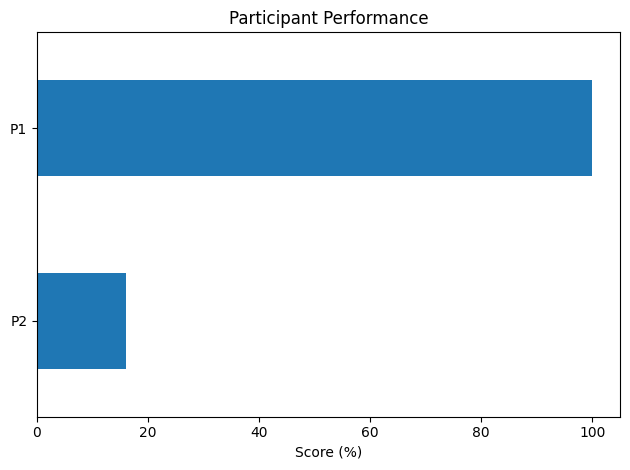


👤 PARTICIPANT: P1
we drove to the park                       | 100.0%
i will call her tomorrow night             | 100.0%

👤 PARTICIPANT: P2
we drove to the park                       | 32.0%
i will call her tomorrow night             | 0.0%

✅ Saved: dashboard_results.csv


In [26]:
# ============================================
# AUTO INSTALL
# ============================================

import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

for pkg in ["jiwer", "rapidfuzz", "langid", "pandas", "matplotlib"]:
    try:
        __import__(pkg)
    except:
        install(pkg)

# ============================================
# IMPORTS
# ============================================

from jiwer import wer
from rapidfuzz import fuzz
import pandas as pd
import langid
import matplotlib.pyplot as plt
import re

try:
    from src.postprocessing import clean_text
except:
    def clean_text(x): return x

# ============================================
# CONFIG
# ============================================

WER_WEIGHT = 0.7
SIM_WEIGHT = 0.3
SIM_THRESHOLD = 0.6
WER_THRESHOLD = 0.8

# ============================================
# UTIL FUNCTIONS
# ============================================

def normalize(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return clean_text(text.strip())

def safe_detect(text):
    try:
        return langid.classify(text)[0]
    except:
        return "unknown"

def compute_metrics(ref, pred):
    return wer(ref, pred), fuzz.ratio(ref, pred) / 100

def compute_score(w, s):
    return max(0, ((1 - w) * WER_WEIGHT + s * SIM_WEIGHT)) * 100

# ============================================
# MATCHING
# ============================================

def find_best_match(reference, predictions):
    best = {"wer":1, "sim":0, "text":"", "score":0}
    ref_lang = safe_detect(reference)

    for pred in predictions:
        p = normalize(pred)
        if safe_detect(p) != ref_lang:
            continue

        w, s = compute_metrics(reference, p)

        if s < SIM_THRESHOLD or w > WER_THRESHOLD:
            continue

        combined = (1 - w)*0.6 + s*0.4

        if combined > best["score"]:
            best = {"wer":w, "sim":s, "text":pred, "score":combined}

    if best["text"] == "":
        return {"wer":1, "sim":0, "text":"[NO MATCH]"}

    return best

# ============================================
# PROCESS ALL FIRST (IMPORTANT CHANGE)
# ============================================

def process_all(precomputed_results, references):
    all_rows = []
    summary = {}

    for participant, data in precomputed_results.items():
        total_wer, total_sim = 0, 0

        for ref in references:
            ref_clean = normalize(ref)
            best = find_best_match(ref_clean, data["sentences"])

            score = compute_score(best["wer"], best["sim"])

            total_wer += best["wer"]
            total_sim += best["sim"]

            all_rows.append({
                "Participant": participant,
                "Reference": ref,
                "Prediction": best["text"],
                "WER": best["wer"],
                "Similarity": best["sim"],
                "Score": score
            })

        avg_wer = total_wer / len(references)
        avg_sim = total_sim / len(references)
        final = compute_score(avg_wer, avg_sim)

        summary[participant] = final

    return pd.DataFrame(all_rows), summary

# ============================================
# DASHBOARD (SHOW FIRST)
# ============================================

def show_dashboard(df, summary):
    print("\n" + "="*70)
    print("📊 OVERALL DASHBOARD")
    print("="*70)

    # Leaderboard
    sorted_scores = sorted(summary.items(), key=lambda x: x[1], reverse=True)

    print("\n🏆 Leaderboard:")
    for p, s in sorted_scores:
        print(f"{p:<25} → {s:.2f}%")

    # Stats
    print("\n📈 Stats:")
    print(f"Average Score: {df['Score'].mean():.2f}%")
    print(f"Best Score: {df['Score'].max():.2f}%")
    print(f"Worst Score: {df['Score'].min():.2f}%")

    # Plot
    plt.figure()
    pd.Series(summary).sort_values().plot(kind="barh")
    plt.title("Participant Performance")
    plt.xlabel("Score (%)")
    plt.tight_layout()
    plt.show()

# ============================================
# INDIVIDUAL VIEW (AFTER DASHBOARD)
# ============================================

def show_individual(df):
    for participant in df["Participant"].unique():
        print("\n" + "="*70)
        print(f"👤 PARTICIPANT: {participant}")
        print("="*70)

        sub = df[df["Participant"] == participant]

        for _, row in sub.iterrows():
            ref = row["Reference"][:40]
            print(f"{ref:<42} | {row['Score']:.1f}%")

# ============================================
# MAIN
# ============================================

def main(precomputed_results, references):
    df, summary = process_all(precomputed_results, references)

    # ✅ FIRST → DASHBOARD
    show_dashboard(df, summary)

    # ✅ THEN → INDIVIDUAL DETAILS
    show_individual(df)

    df.to_csv("dashboard_results.csv", index=False)
    print("\n✅ Saved: dashboard_results.csv")

# ============================================
# RUN
# ============================================

main(precomputed_results, REFERENCE_SENTENCES)

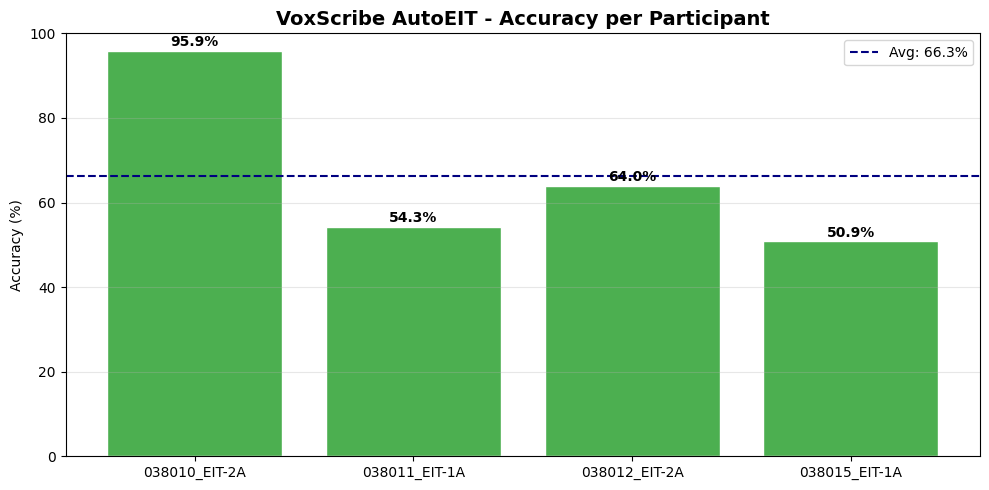

Chart saved!


In [20]:
# Dashboard Chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4CAF50' if s >= 50 else '#FF9800' for s in all_scores.values()]
bars = ax.bar(all_scores.keys(), all_scores.values(), color=colors, edgecolor='white')
ax.set_title("VoxScribe AutoEIT - Accuracy per Participant", fontsize=14, fontweight='bold')
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)
for bar, val in zip(bars, all_scores.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontweight='bold')
ax.axhline(y=sum(all_scores.values())/len(all_scores), color='navy',
           linestyle='--', label=f"Avg: {sum(all_scores.values())/len(all_scores):.1f}%")
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(r"C:\Users\khush\portfolio\voxscribe-autoEIT\results\dashboard.png", dpi=150)
plt.show()
print("Chart saved!")

     ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
     ----- ---------------------------------- 0.3/1.9 MB ? eta -:--:--
     ----- ---------------------------------- 0.3/1.9 MB ? eta -:--:--
     ----- ---------------------------------- 0.3/1.9 MB ? eta -:--:--
     ----- ---------------------------------- 0.3/1.9 MB ? eta -:--:--
     -

In [29]:
# Run everything here
df, summary = process_all(precomputed_results, REFERENCE_SENTENCES)

df.head()

,Participant,Reference,Prediction,WER,Similarity,Score
0,038010_EIT-2A,we drove to the park,We drove to the park,0.000000,1.000000,100.000000
1,038010_EIT-2A,i will call her tomorrow night,I'll call her tomorrow night,0.333333,0.947368,75.087719
2,038011_EIT-1A,we drove to the park,Drove to park,0.400000,0.787879,65.636364
3,038011_EIT-1A,i will call her tomorrow night,Call tomorrow night,0.500000,0.775510,58.265306


In [30]:
print("Leaderboard:")
for k, v in summary.items():
    print(k, "->", round(v, 2), "%")

Leaderboard:
038010_EIT-2A -> 87.54 %
038011_EIT-1A -> 61.95 %


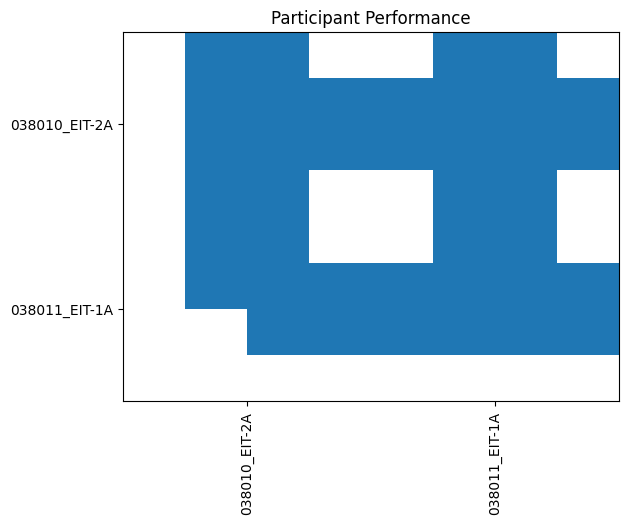

In [31]:
import matplotlib.pyplot as plt

pd.Series(summary).sort_values().plot(kind="barh")
plt.title("Participant Performance")
plt.show()

In [33]:
!pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

